In [76]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd
from AdrenalInstance import AdrenalInstance

In [ ]:
# get delaytime and washout info from filename
from config import DATA_ROOT_DIR
Feature_data_dir = os.path.join(DATA_ROOT_DIR, "processed_data/grouped_instance_features")
Group5_feature_csv_file = os.path.join(Feature_data_dir, "Group5_features.csv")
Group7_feature_csv_file = os.path.join(Feature_data_dir, "Group7_features.csv")

Instance_data_dir = os.path.join(DATA_ROOT_DIR, "processed_data/split_pixel_data_adjusted")

In [ ]:

processed_data_root_dir = os.path.join(DATA_ROOT_DIR, "processed_data")
clinical_data_file = os.path.join(processed_data_root_dir, "mrn_malignancy.csv")
HU_data_dir = os.path.join(processed_data_root_dir, "HU_array_adjusted")
Image_data_dir = os.path.join(processed_data_root_dir, "reconstructed_img_adjusted")
# Output directory for saving feature CSV files


In [79]:
df5 = pd.read_csv(Group5_feature_csv_file)
df5 = df5[["MRN", "StudyDate", "relative_washout", "absolute_washout", "relative_washout_rate", "absolute_washout_rate", "malignancy"]]
mrn = df5["MRN"].values
study_date = df5["StudyDate"].values
# absolute_washout = df5["AbsoluteWashout"].values
# relative_washout = df5["RelativeWashout"].values
# absolute_washout_rate = df5["AbsoluteWashoutRate"].values
# relative_washout_rate = df5["RelativeWashoutRate"].values

all_mrn_study_dates = {"MRN", "StudyDate", "relative_washout", "absolute_washout", "relative_washout_rate", "absolute_washout_rate"}


df7 = pd.read_csv(Group7_feature_csv_file)
df7 = df7[["MRN", "StudyDate", "relative_washout", "absolute_washout", "relative_washout_rate", "absolute_washout_rate", "malignancy"]]
mrn = df7["MRN"].values
study_date = df7["StudyDate"].values
# absolute_washout = df7["AbsoluteWashout"].values
# relative_washout = df7["RelativeWashout"].values
# absolute_washout_rate = df7["AbsoluteWashoutRate"].values
# relative_washout_rate = df7["RelativeWashoutRate"].values

# merge the two dataframes on MRN and StudyDate, and keep all washout-related columns
merged_df = pd.concat([df5, df7])

print(merged_df.head())

      MRN  StudyDate  relative_washout  absolute_washout  \
0  740912   20080215         18.068521         33.456132   
1  697388   20071220         31.861782         41.844052   
2  744646   20080523          0.794849          2.695141   
3  376010   20080701        -28.701985        -53.596255   
4  750840   20080528         24.217688         23.013511   

   relative_washout_rate  absolute_washout_rate  malignancy  
0               0.144548               0.267649           1  
1               0.274671               0.360725           0  
2               0.006114               0.020732           1  
3              -0.185174              -0.345782           1  
4               0.195304               0.185593           1  


In [80]:
# get delay time based on MRN and StudyDate

for mrn, study_date in merged_df[["MRN", "StudyDate"]].values:
    # find the corresponding pixel data file
    pattern = f"{mrn}_{study_date}.csv"
    raw_data_fn = os.path.join(Instance_data_dir, pattern)
    # print(f"Looking for file: {raw_data_fn}"    )
    if os.path.exists(raw_data_fn):
        ad_instance = AdrenalInstance(str(mrn), str(study_date), HU_data_dir, Image_data_dir)
        delay_time = ad_instance.phase_delta_t["Delay"]
        # print(f"MRN: {mrn}, StudyDate: {study_date}, Delay Time (min): {delay_time}")
        merged_df.loc[(merged_df["MRN"] == mrn) & (merged_df["StudyDate"] == study_date), "DelayTime"] = delay_time/60  # convert seconds to minutes


In [81]:
plt.rcParams.update({'font.size': 14}) 

/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_37345/346996765.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


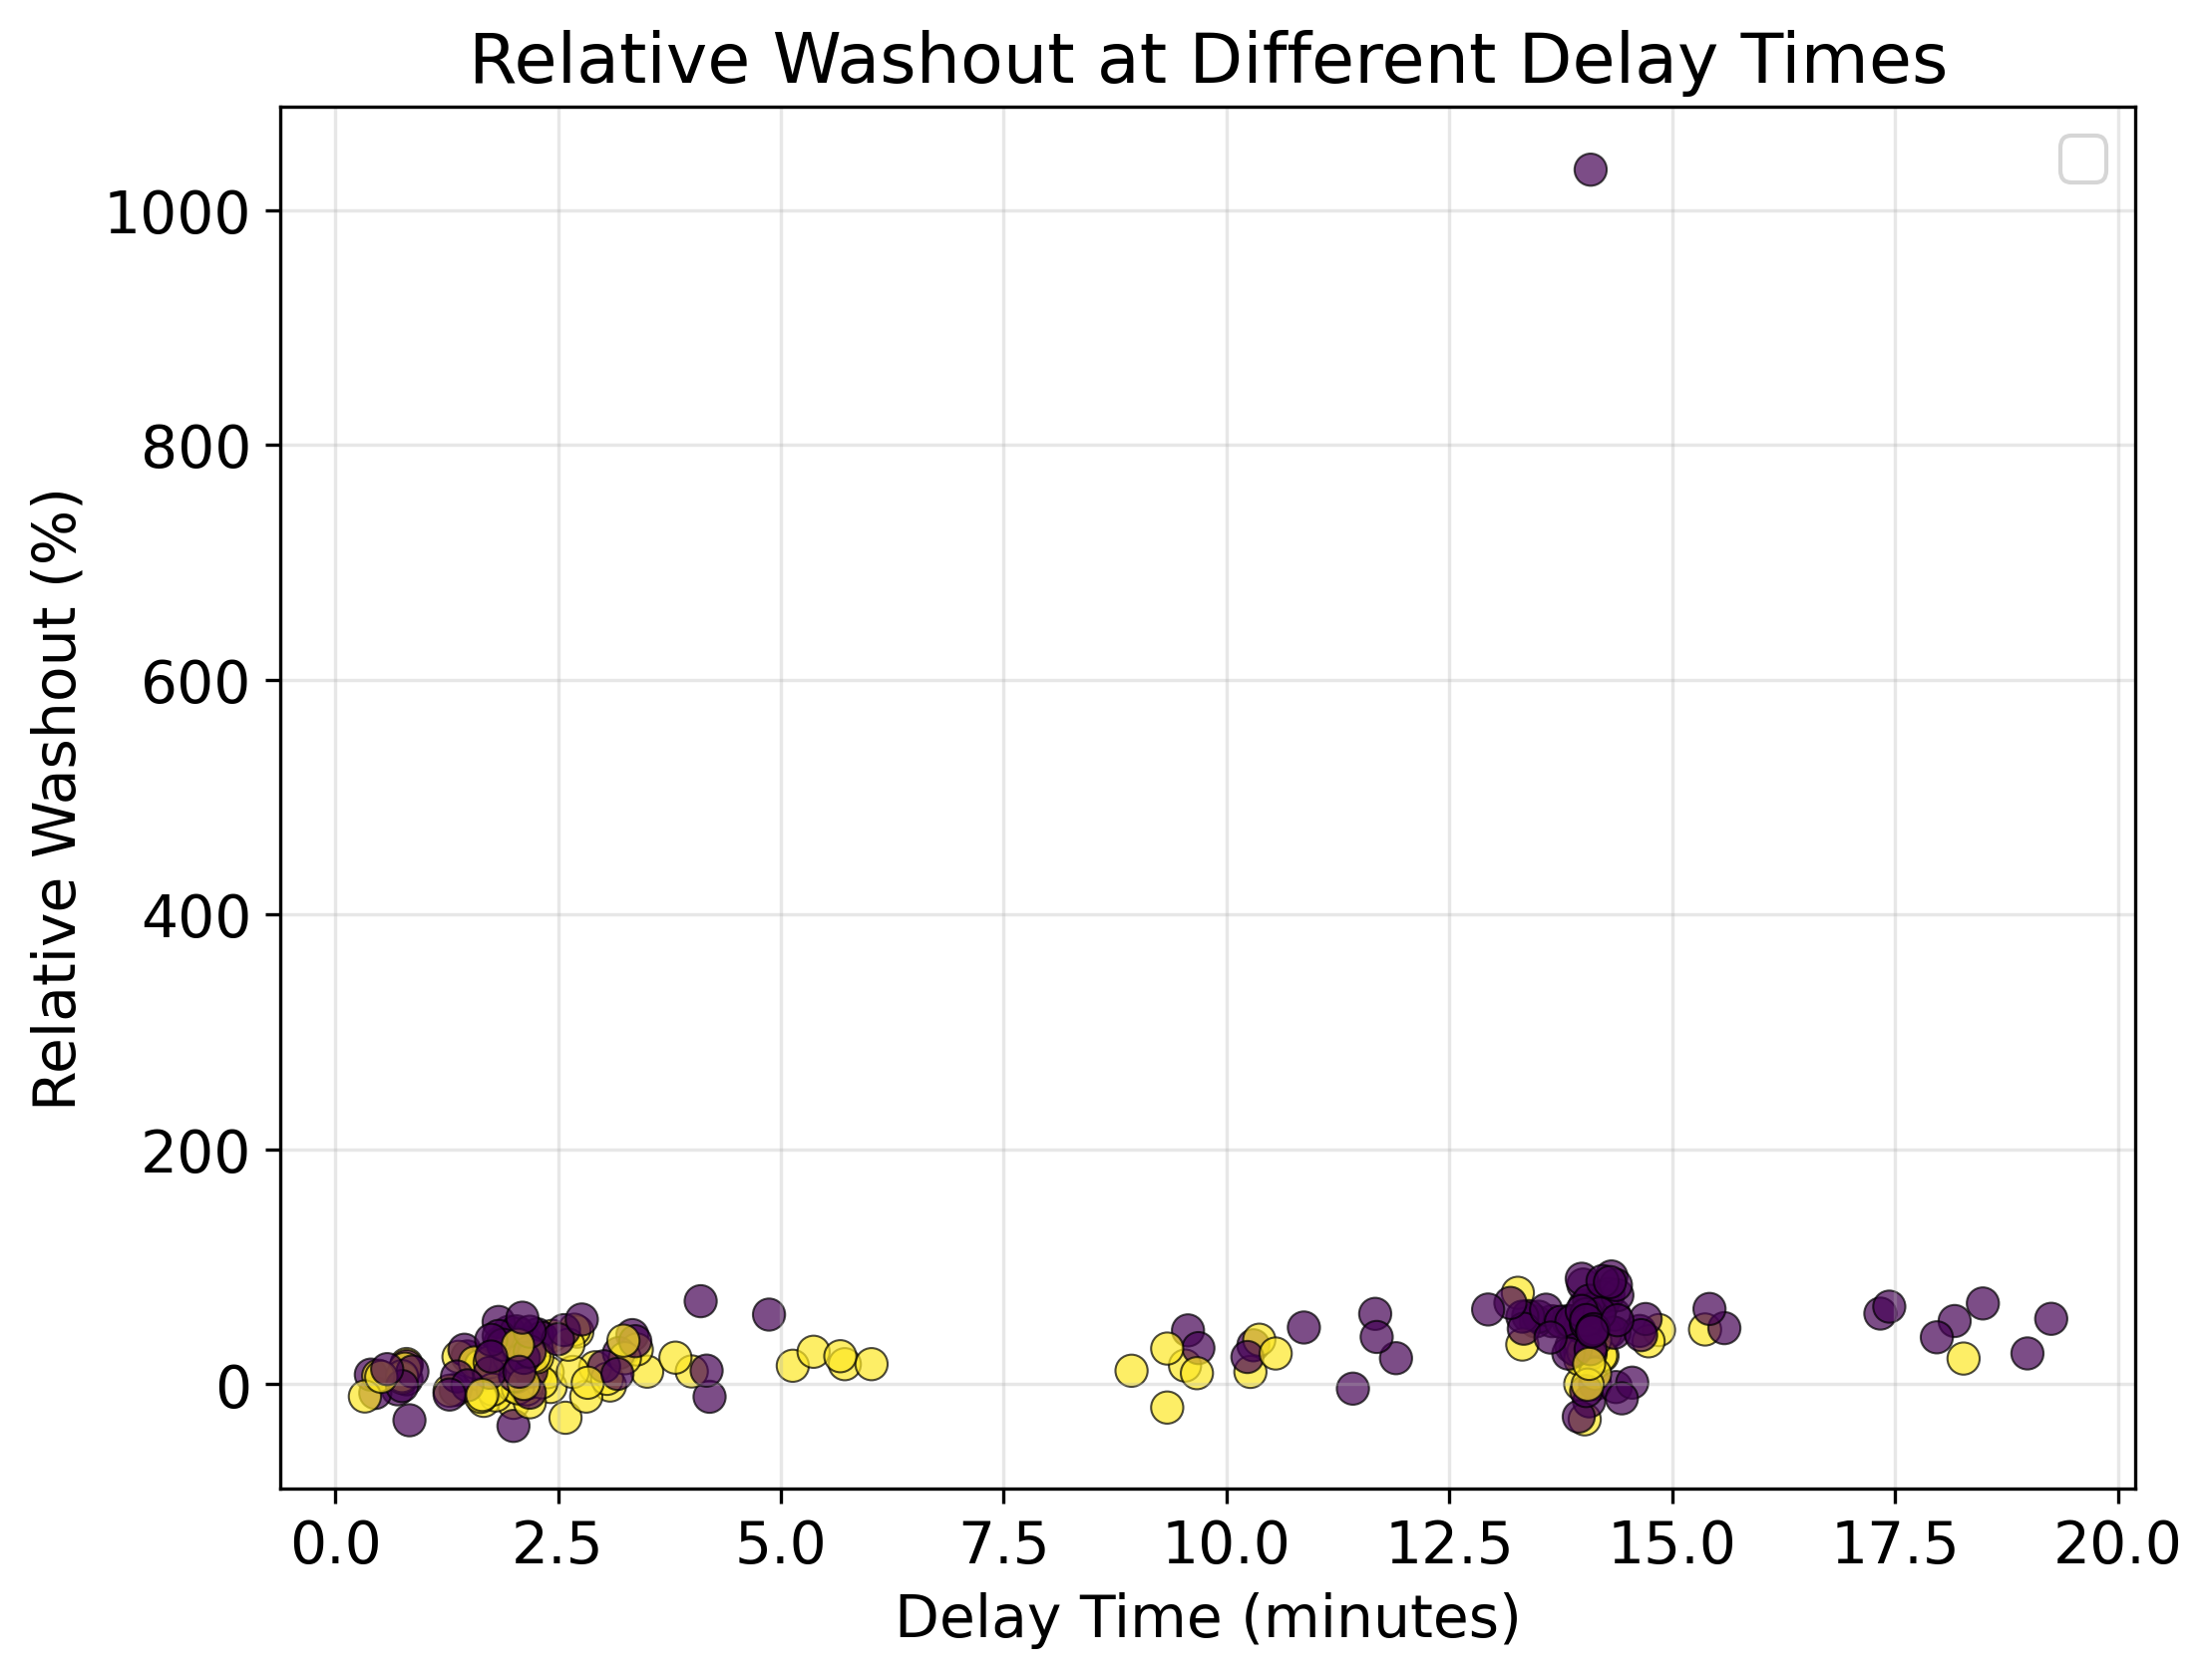

In [82]:
# 2. Scatter plot: Relative Washout vs Delay Time
plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(merged_df["DelayTime"], merged_df["relative_washout"], 
        alpha=0.7, s=60, edgecolors='black', linewidth=0.5, c=merged_df["malignancy"])
# plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero washout')
# plt.axhline(y=60, color='green', linestyle='--', alpha=0.7, label='60% threshold')
plt.xlabel('Delay Time (minutes)')
plt.ylabel('Relative Washout (%)')
plt.title('Relative Washout at Different Delay Times')
plt.grid(True, alpha=0.3)
plt.legend()

/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_37345/4080139758.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["malignancy"] = filtered_df["malignancy"].map({0: 'blue', 1: 'red'})


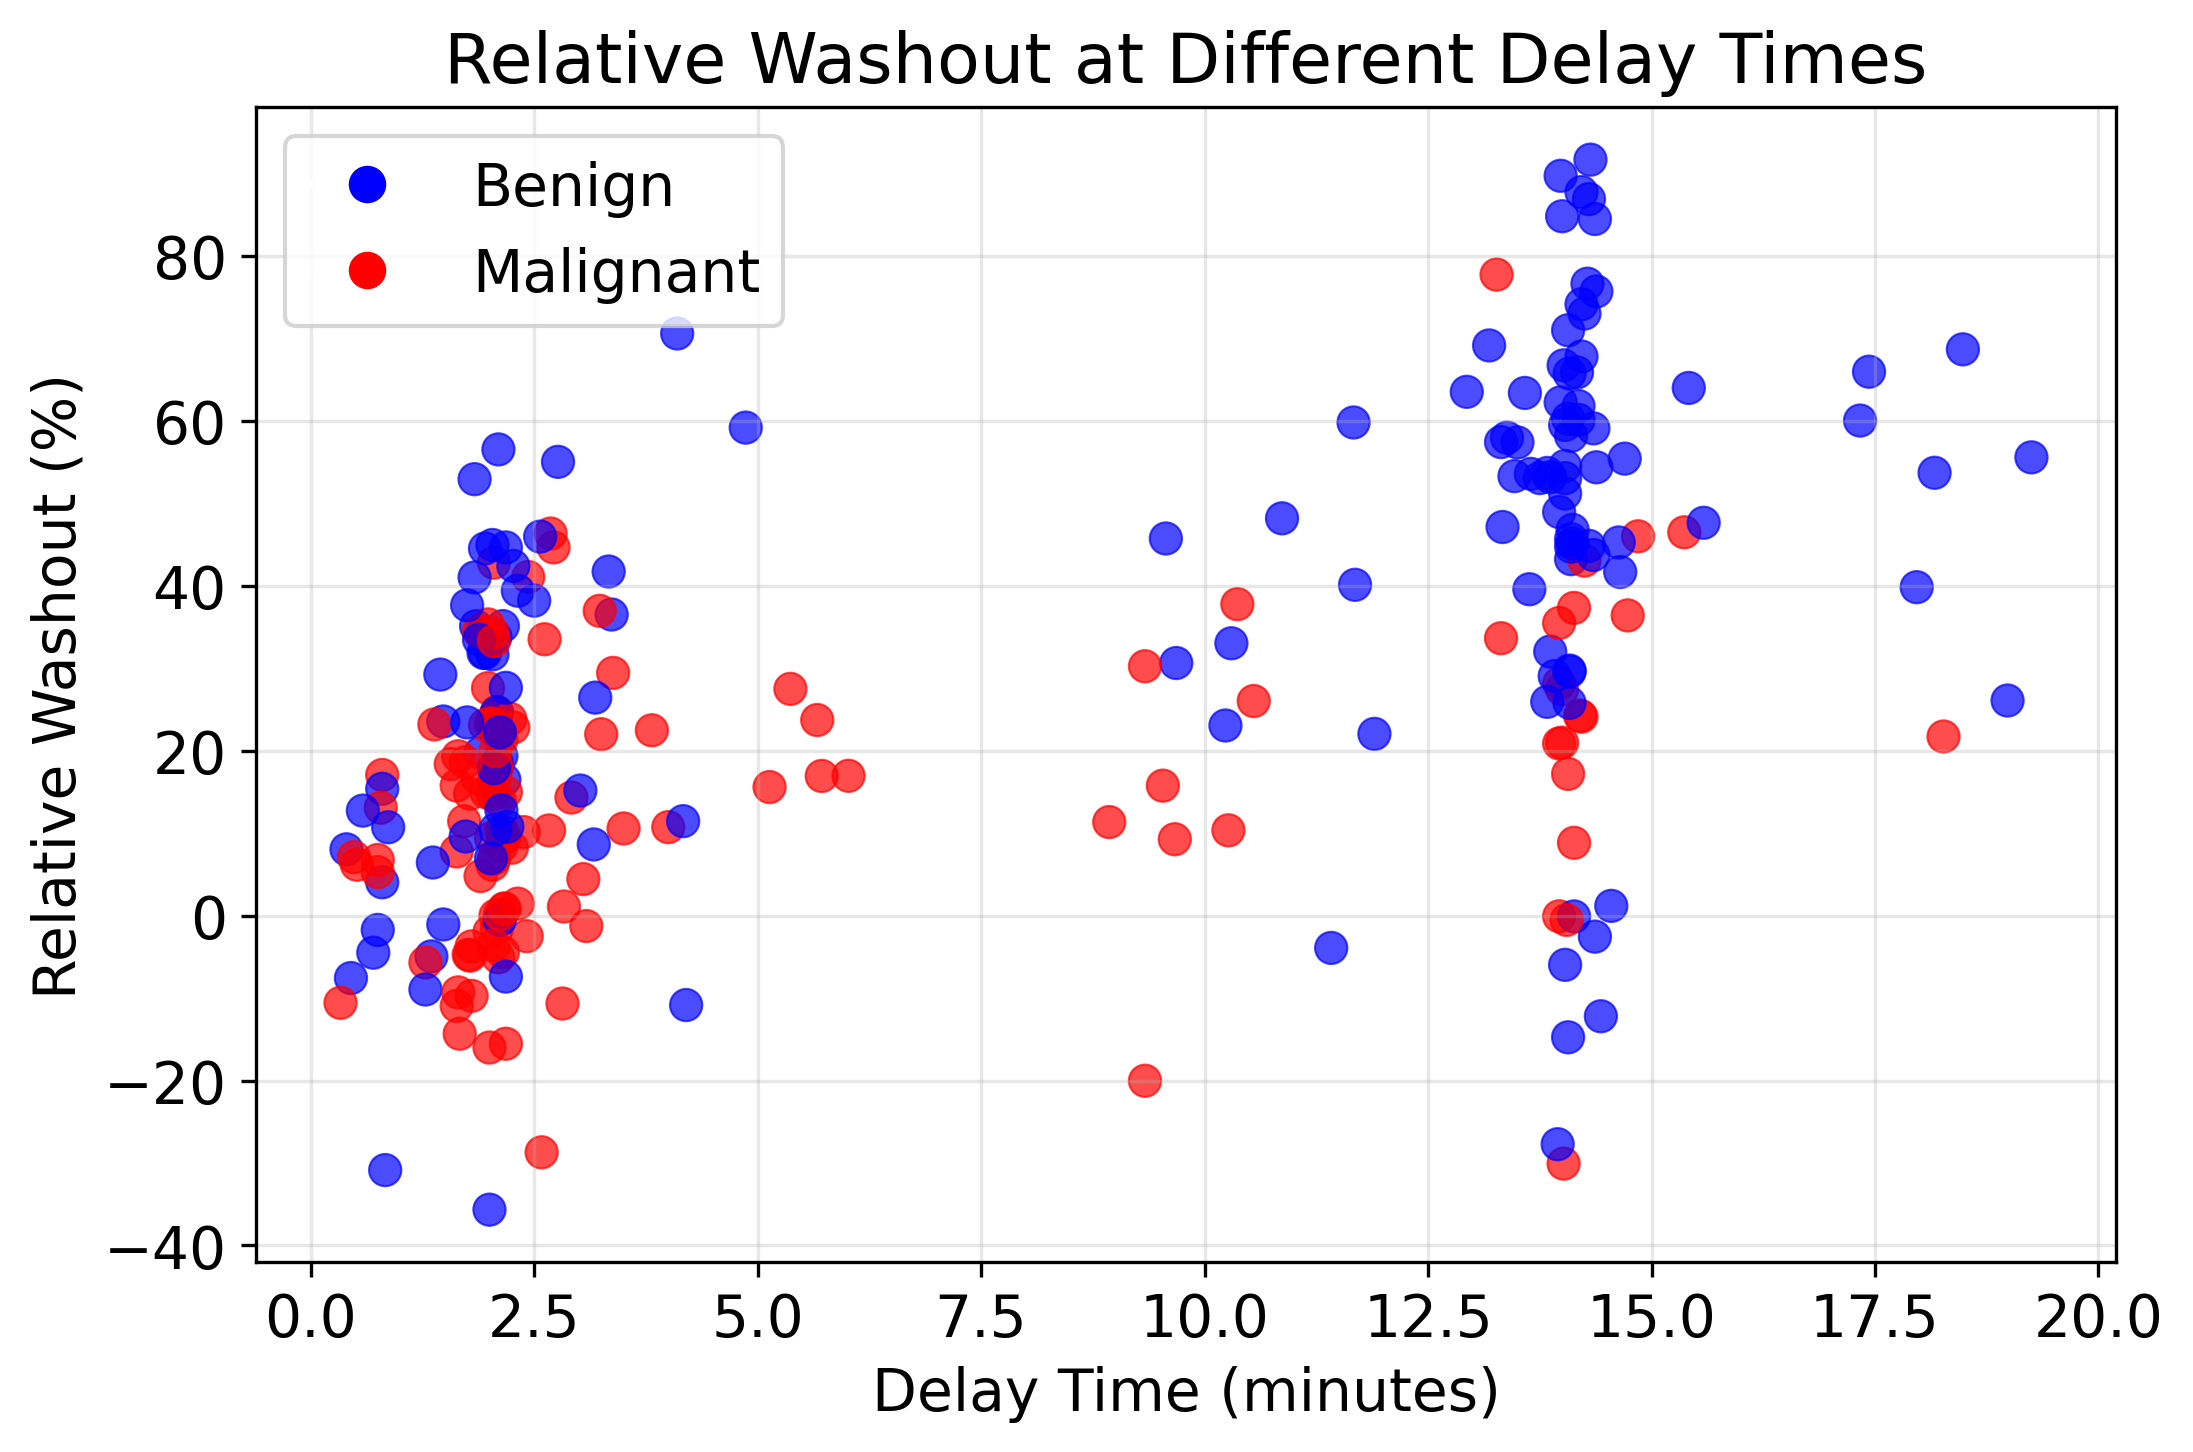

In [83]:
# exclude outliers with washout > 200%
filtered_df = merged_df[merged_df["relative_washout"] <= 200]   
# set point colors to red for malignant and blue for benign
filtered_df["malignancy"] = filtered_df["malignancy"].map({0: 'blue', 1: 'red'})

plt.figure(figsize=(8, 5), dpi=300)
plt.scatter(filtered_df["DelayTime"], filtered_df["relative_washout"], 
        alpha=0.7, s=60, linewidth=0.5, c=filtered_df["malignancy"])
# plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero washout')
# plt.axhline(y=60, color='green', linestyle='--', alpha=0.7, label='60% threshold')
plt.xlabel('Delay Time (minutes)')
plt.ylabel('Relative Washout (%)')
plt.title('Relative Washout at Different Delay Times')
plt.grid(True, alpha=0.3)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Benign', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Malignant', markerfacecolor='red', markersize=10)]
plt.legend(handles=legend_elements)  
plt.show()



/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_37345/2086207026.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


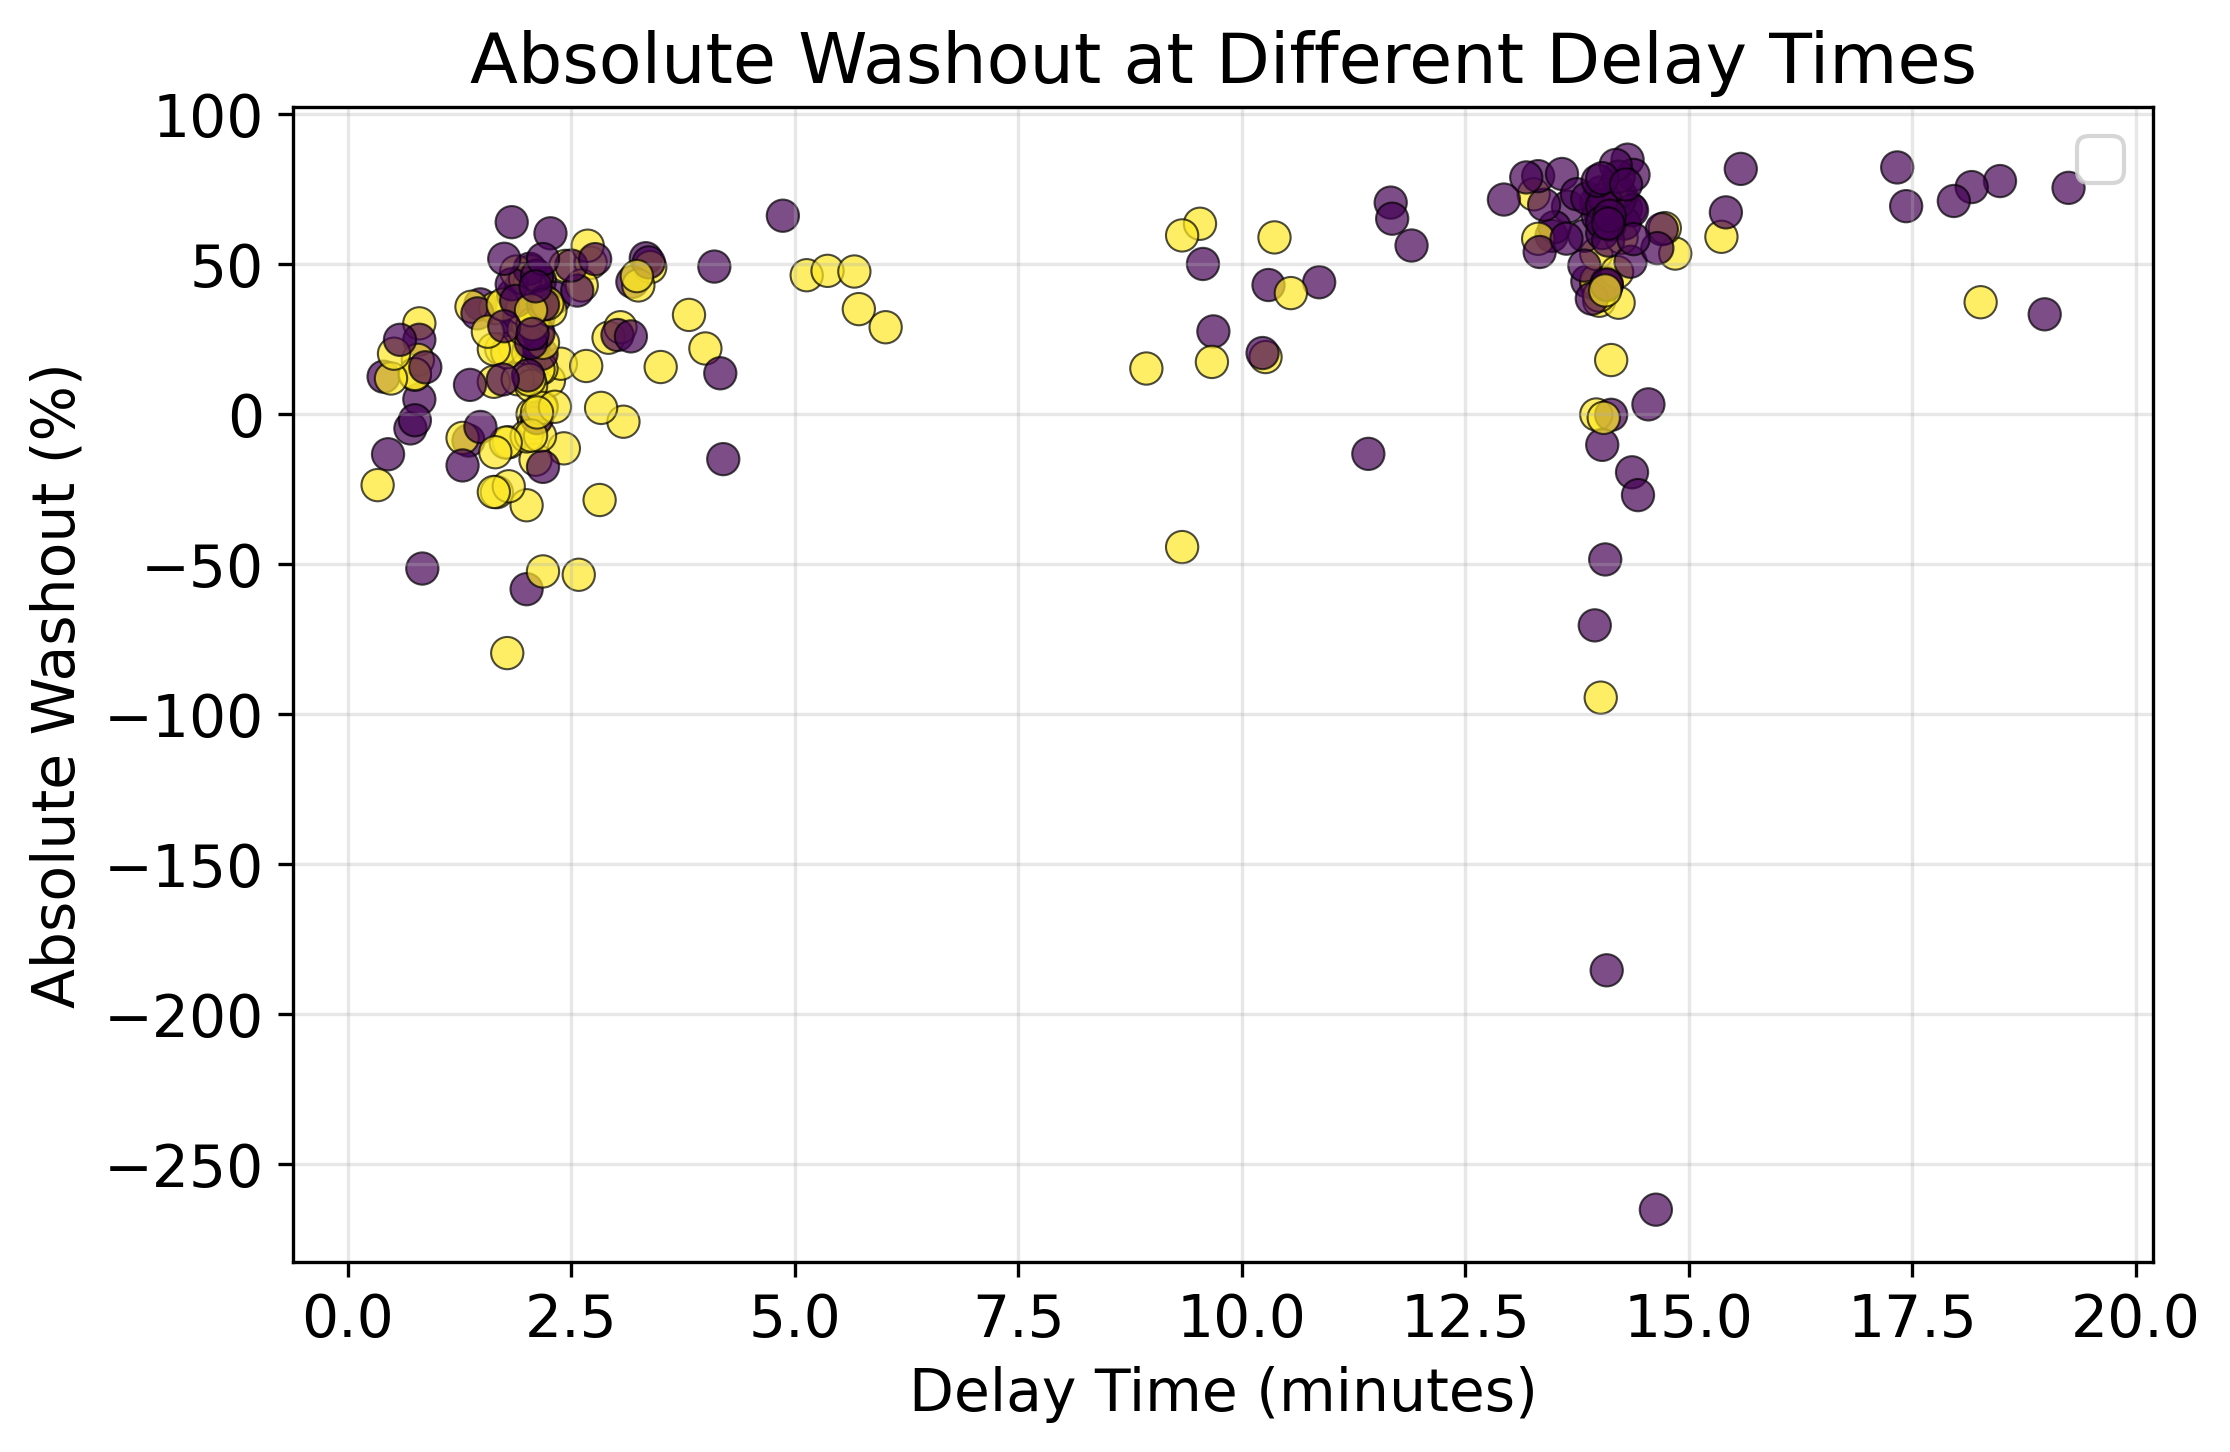

In [84]:
plt.figure(figsize=(8, 5), dpi=300)
plt.scatter(merged_df["DelayTime"], merged_df["absolute_washout"], 
        alpha=0.7, s=60, edgecolors='black', linewidth=0.5, c=merged_df["malignancy"])
# plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero washout')
# plt.axhline(y=60, color='green', linestyle='--', alpha=0.7, label='60% threshold')
plt.xlabel('Delay Time (minutes)')
plt.ylabel('Absolute Washout (%)')
plt.title('Absolute Washout at Different Delay Times')
plt.grid(True, alpha=0.3)
plt.legend()

/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_37345/699450423.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["malignancy"] = filtered_df["malignancy"].map({0: 'blue', 1: 'red'})


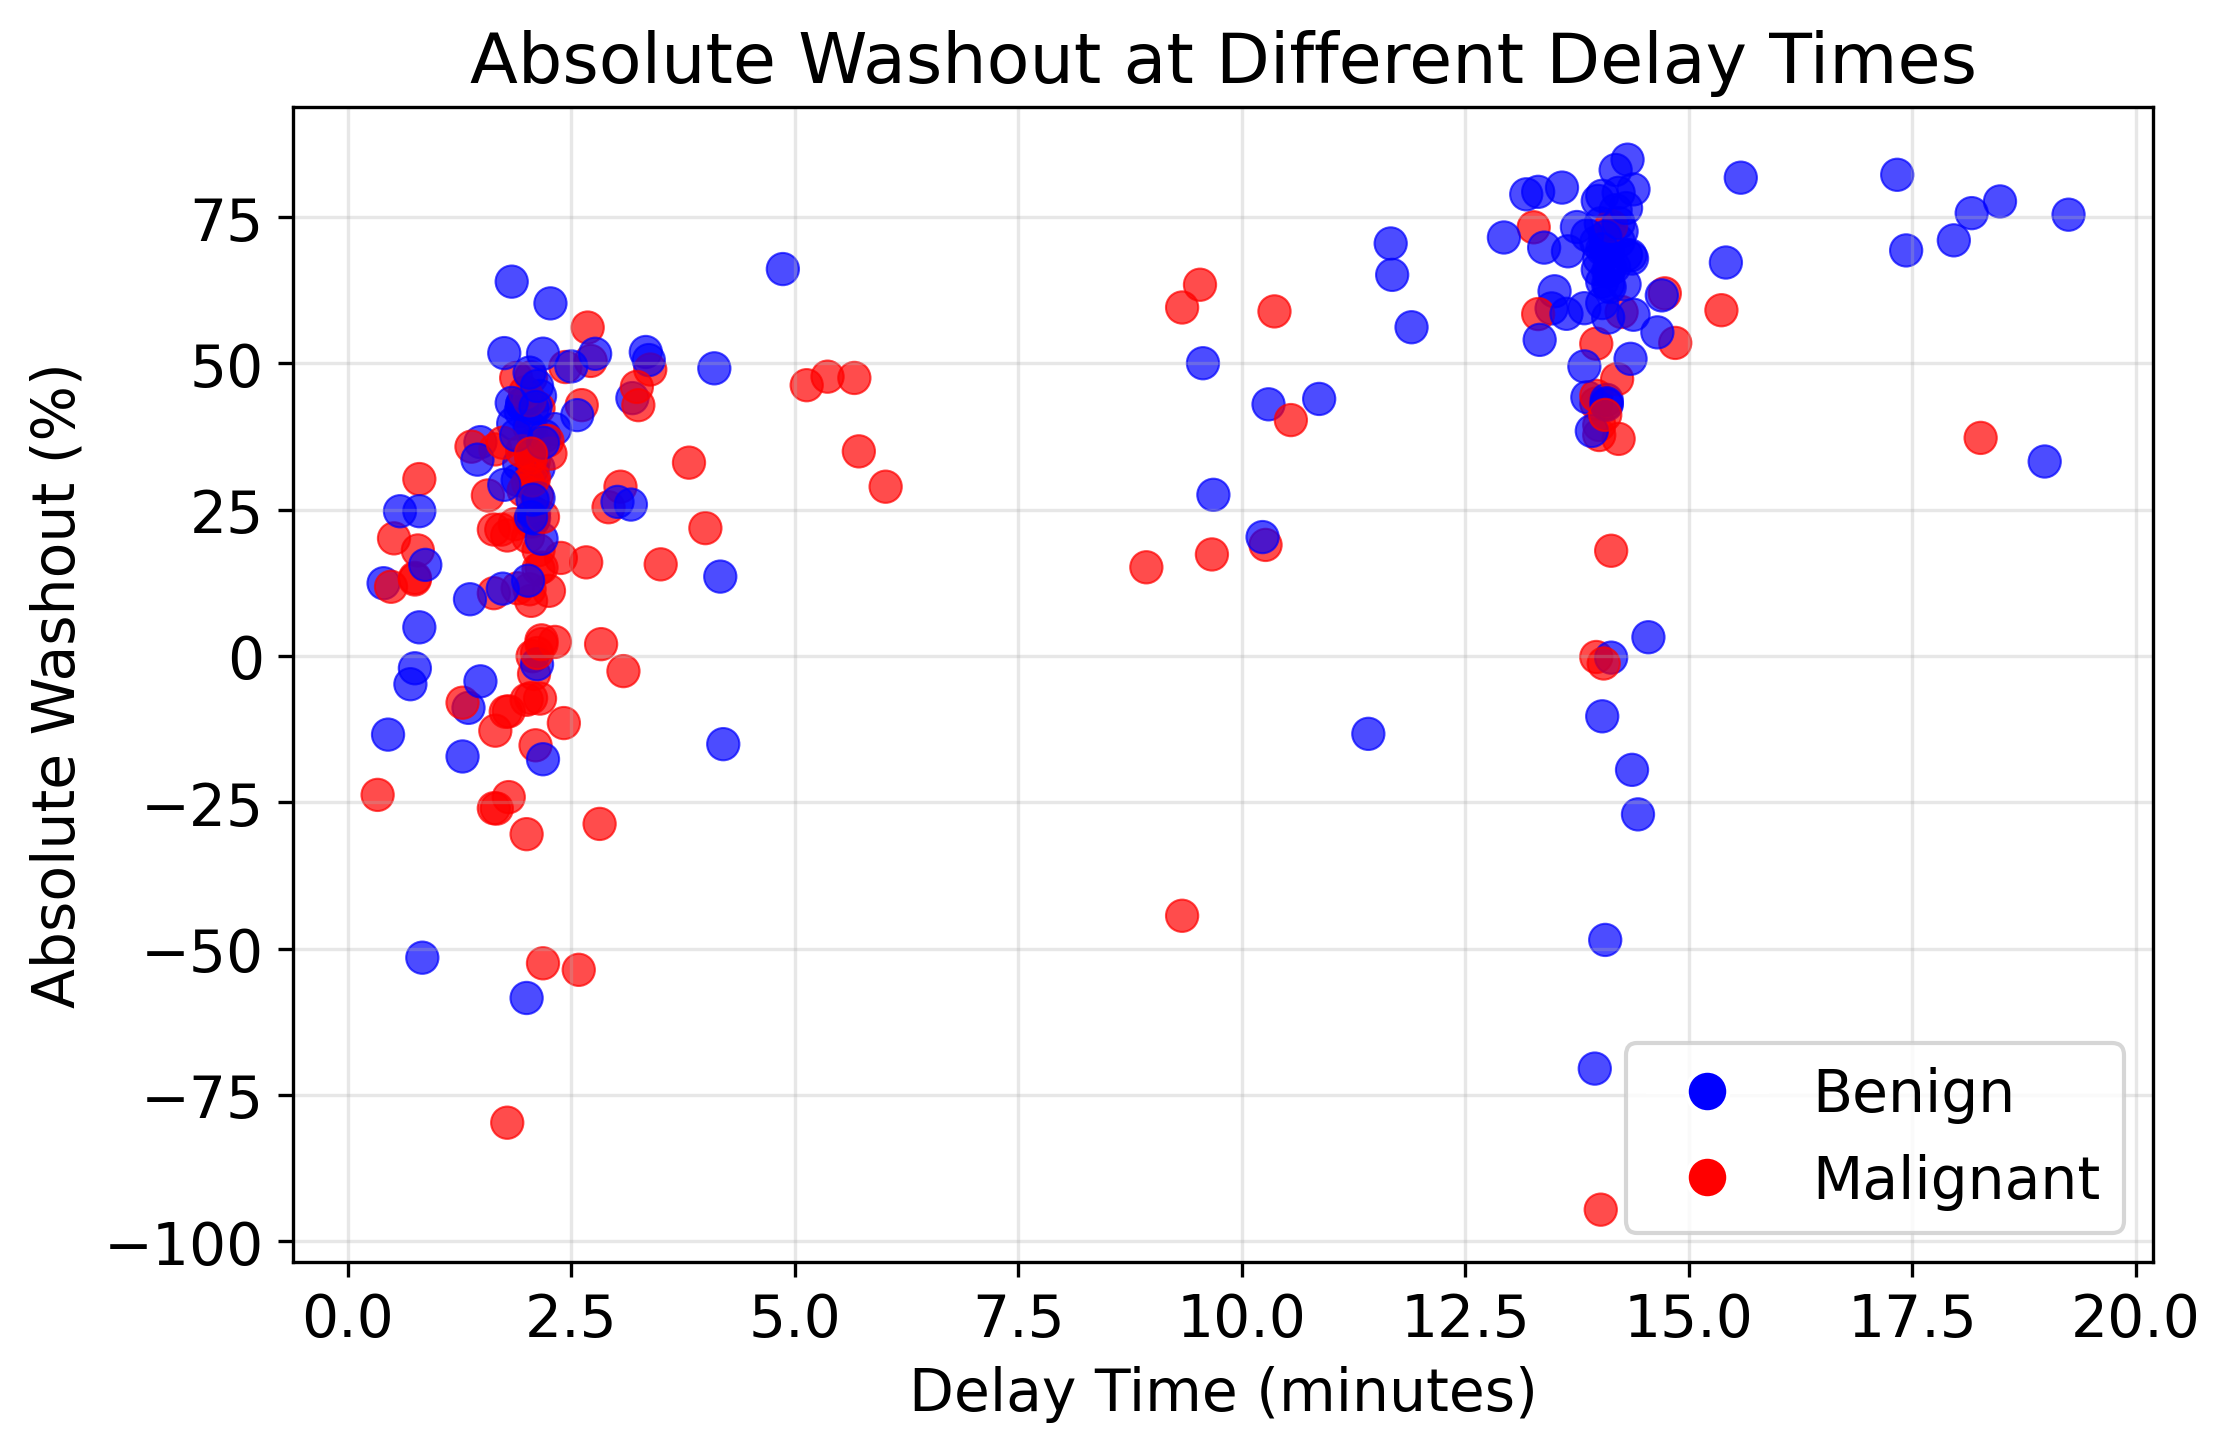

In [85]:
# exclude outliers with washout > 200%
filtered_df = merged_df[merged_df["absolute_washout"] >= -150]   
# set point colors to red for malignant and blue for benign
filtered_df["malignancy"] = filtered_df["malignancy"].map({0: 'blue', 1: 'red'})

plt.figure(figsize=(8, 5), dpi=300)
plt.scatter(filtered_df["DelayTime"], filtered_df["absolute_washout"], 
        alpha=0.7, s=60, linewidth=0.5, c=filtered_df["malignancy"])
# plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero washout')
# plt.axhline(y=60, color='green', linestyle='--', alpha=0.7, label='60% threshold')
plt.xlabel('Delay Time (minutes)')
plt.ylabel('Absolute Washout (%)')
plt.title('Absolute Washout at Different Delay Times')
plt.grid(True, alpha=0.3)
# add legend for color coding
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Benign', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Malignant', markerfacecolor='red', markersize=10)]
plt.legend(handles=legend_elements)
plt.show()


In [ ]:
# read pathology diagnosis from csv 
from config import DATA_ROOT_DIR
clinical_data_dir = os.path.join(DATA_ROOT_DIR, "original_data/data_clinical")
cohort_df = pd.read_csv(os.path.join(clinical_data_dir, "cohort_clinical_analysis.csv"))
# mearge with merged_df to get the pathology diagnosis for each study
merged_df_all = pd.merge(merged_df, cohort_df[["MRN", "Pathology"]], on="MRN", how="left")

merged_df_all.to_csv(os.path.join(clinical_data_dir, "merged_df_all.csv"), index=False)

# set point colors based on pathology diagnosis
pathology_colors = {
    "Metastasis": 'red',
    "Adenoma": 'blue',
    "Pheochromocytoma": 'green',
    "ACC": 'orange',
    "Hyperplasia": 'purple'
}

# map all other pathologies to gray
merged_df_all["Pathology"] = merged_df_all["Pathology"].map(lambda x: x if x in pathology_colors else "Other")
pathology_colors["Other"] = 'gray'
merged_df_all["color"] = merged_df_all["Pathology"].map(pathology_colors)



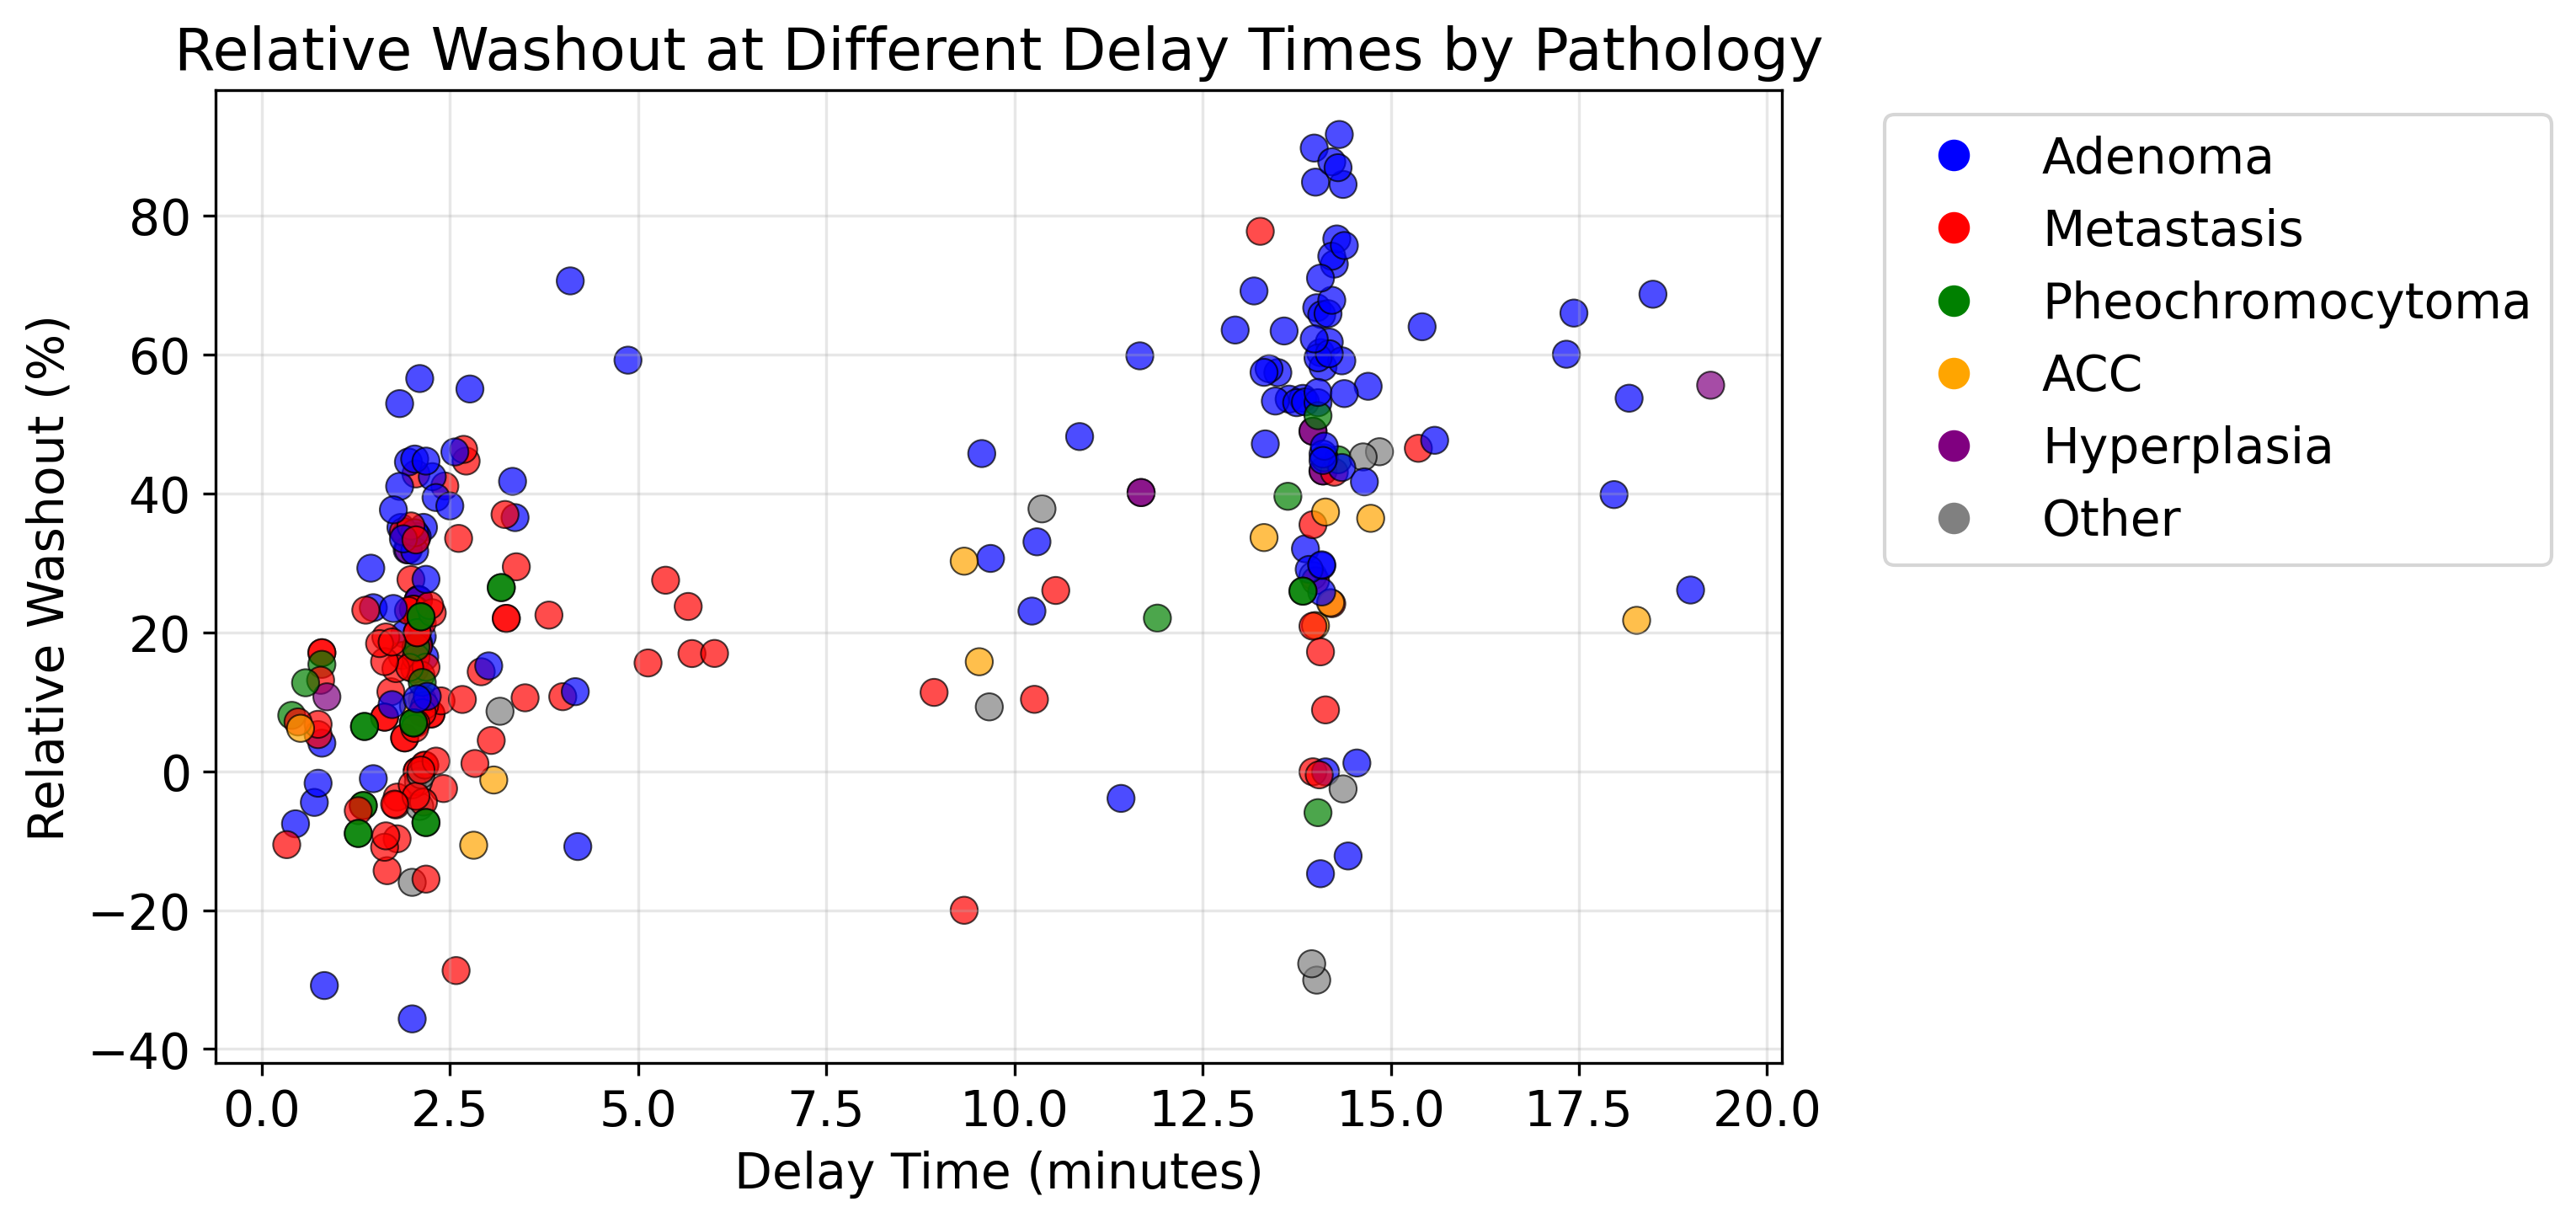

In [87]:
filtered_df = merged_df_all[merged_df_all["relative_washout"] <= 200]  
plt.figure(figsize=(8, 5), dpi=300)
plt.scatter(filtered_df["DelayTime"], filtered_df["relative_washout"], 
        alpha=0.7, s=60, edgecolors='black', linewidth=0.5, c=filtered_df["color"])
plt.xlabel('Delay Time (minutes)')
plt.ylabel('Relative Washout (%)')
plt.title('Relative Washout at Different Delay Times by Pathology')
plt.grid(True, alpha=0.3)
# add legend for color coding
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Adenoma', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Metastasis', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Pheochromocytoma', markerfacecolor='green', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='ACC', markerfacecolor='orange', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Hyperplasia', markerfacecolor='purple', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Other', markerfacecolor='gray', markersize=10)]
# put legend outside of the plot
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.show()

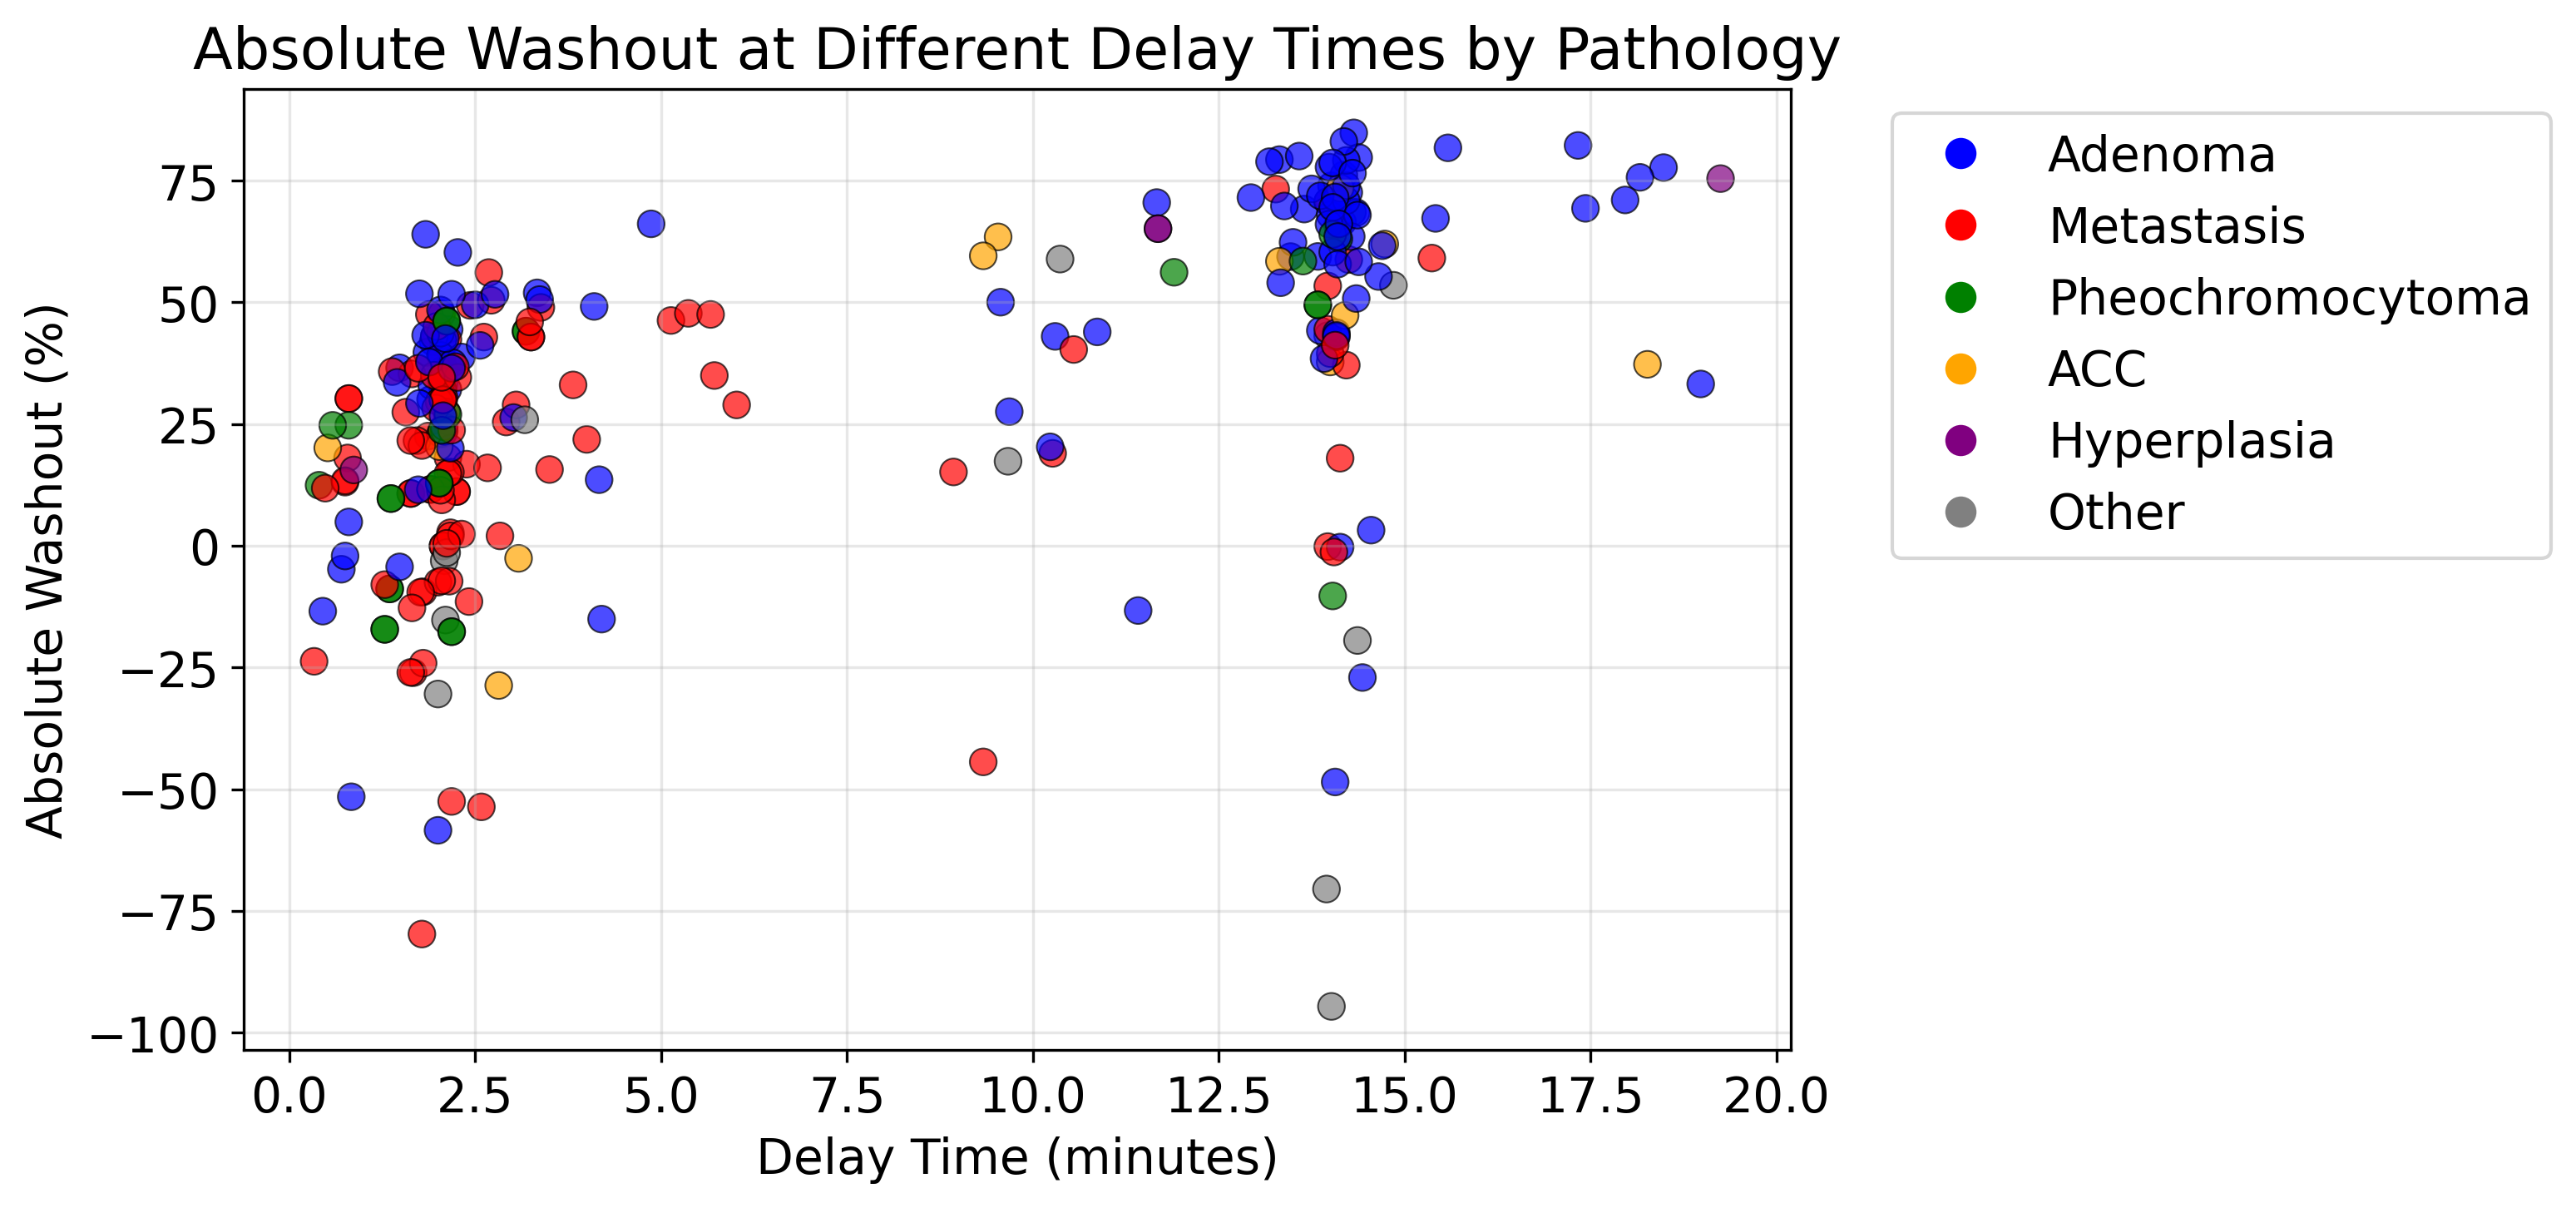

In [88]:
filtered_df = merged_df_all[merged_df_all["absolute_washout"] >= -150]  
plt.figure(figsize=(8, 5), dpi=300)
plt.scatter(filtered_df["DelayTime"], filtered_df["absolute_washout"], 
        alpha=0.7, s=60, edgecolors='black', linewidth=0.5, c=filtered_df["color"])
plt.xlabel('Delay Time (minutes)')
plt.ylabel('Absolute Washout (%)')
plt.title('Absolute Washout at Different Delay Times by Pathology')
plt.grid(True, alpha=0.3)
# add legend for color coding
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Adenoma', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Metastasis', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Pheochromocytoma', markerfacecolor='green', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='ACC', markerfacecolor='orange', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Hyperplasia', markerfacecolor='purple', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Other', markerfacecolor='gray', markersize=10)]
# plt.legend(handles=legend_elements)  
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.show()

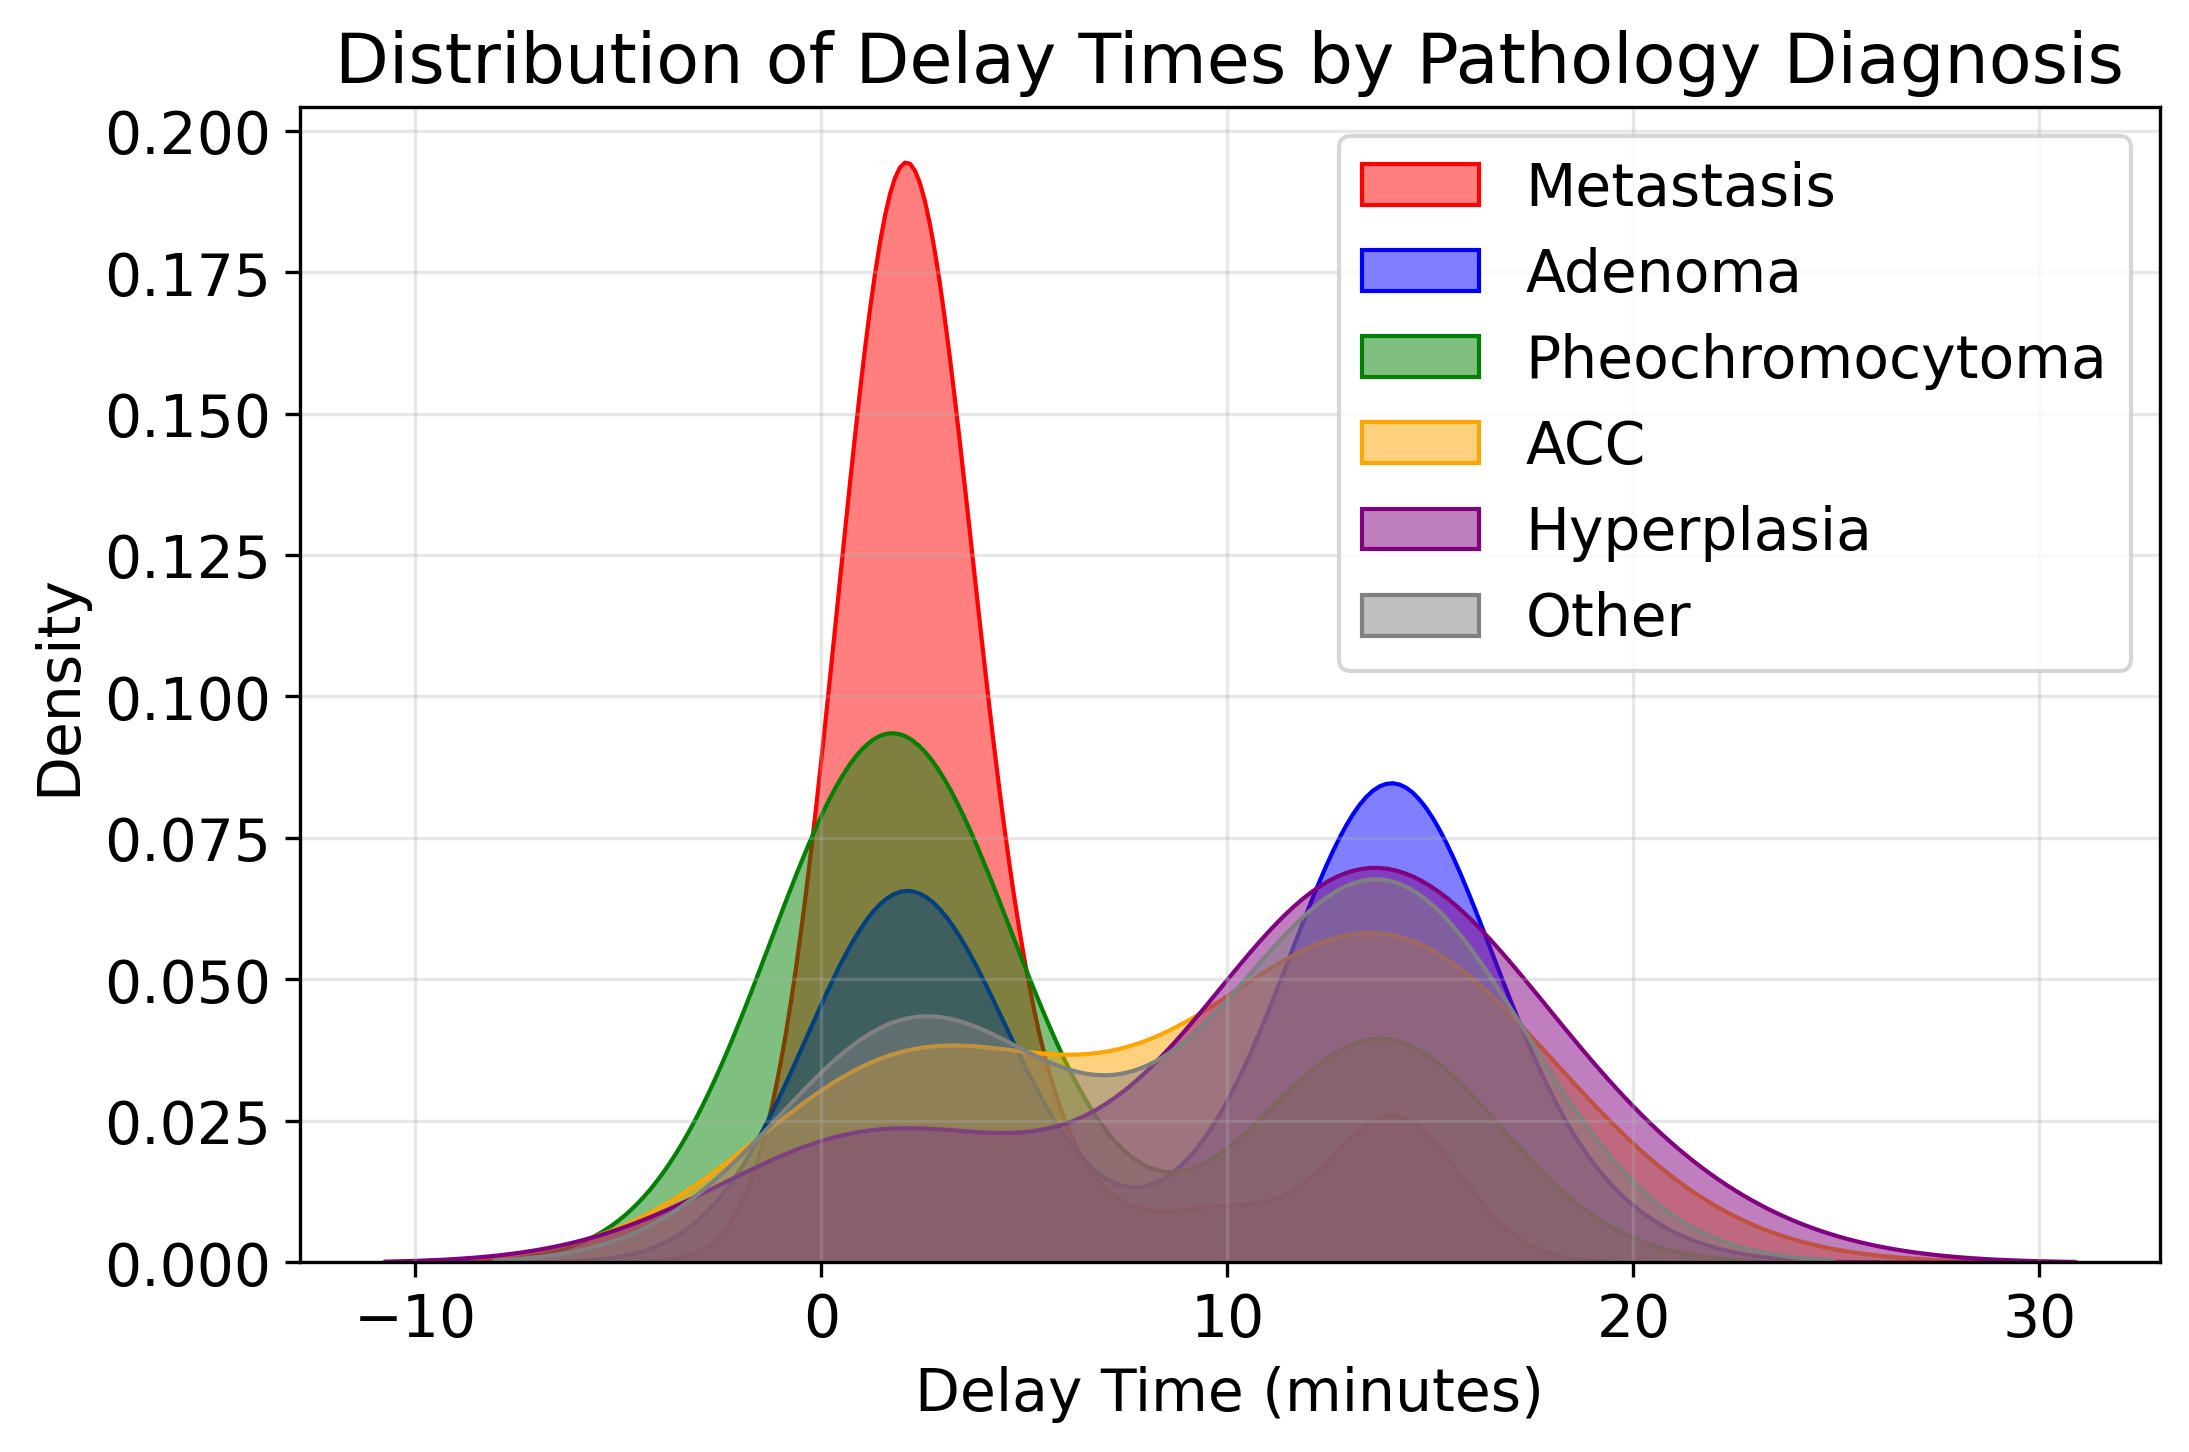

In [89]:
#draw plot, x-axis is delay time, y-axis is count of pathology diagnosis (KDE smoothed), line color code by pathology diagnosis
import seaborn as sns

plt.figure(figsize=(8, 5), dpi=300)
for pathology, color in pathology_colors.items():
    subset = merged_df_all[merged_df_all["Pathology"] == pathology]
    sns.kdeplot(subset["DelayTime"], label=pathology, color=color, fill=True, alpha=0.5)
plt.xlabel('Delay Time (minutes)')
plt.ylabel('Density')
plt.title('Distribution of Delay Times by Pathology Diagnosis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

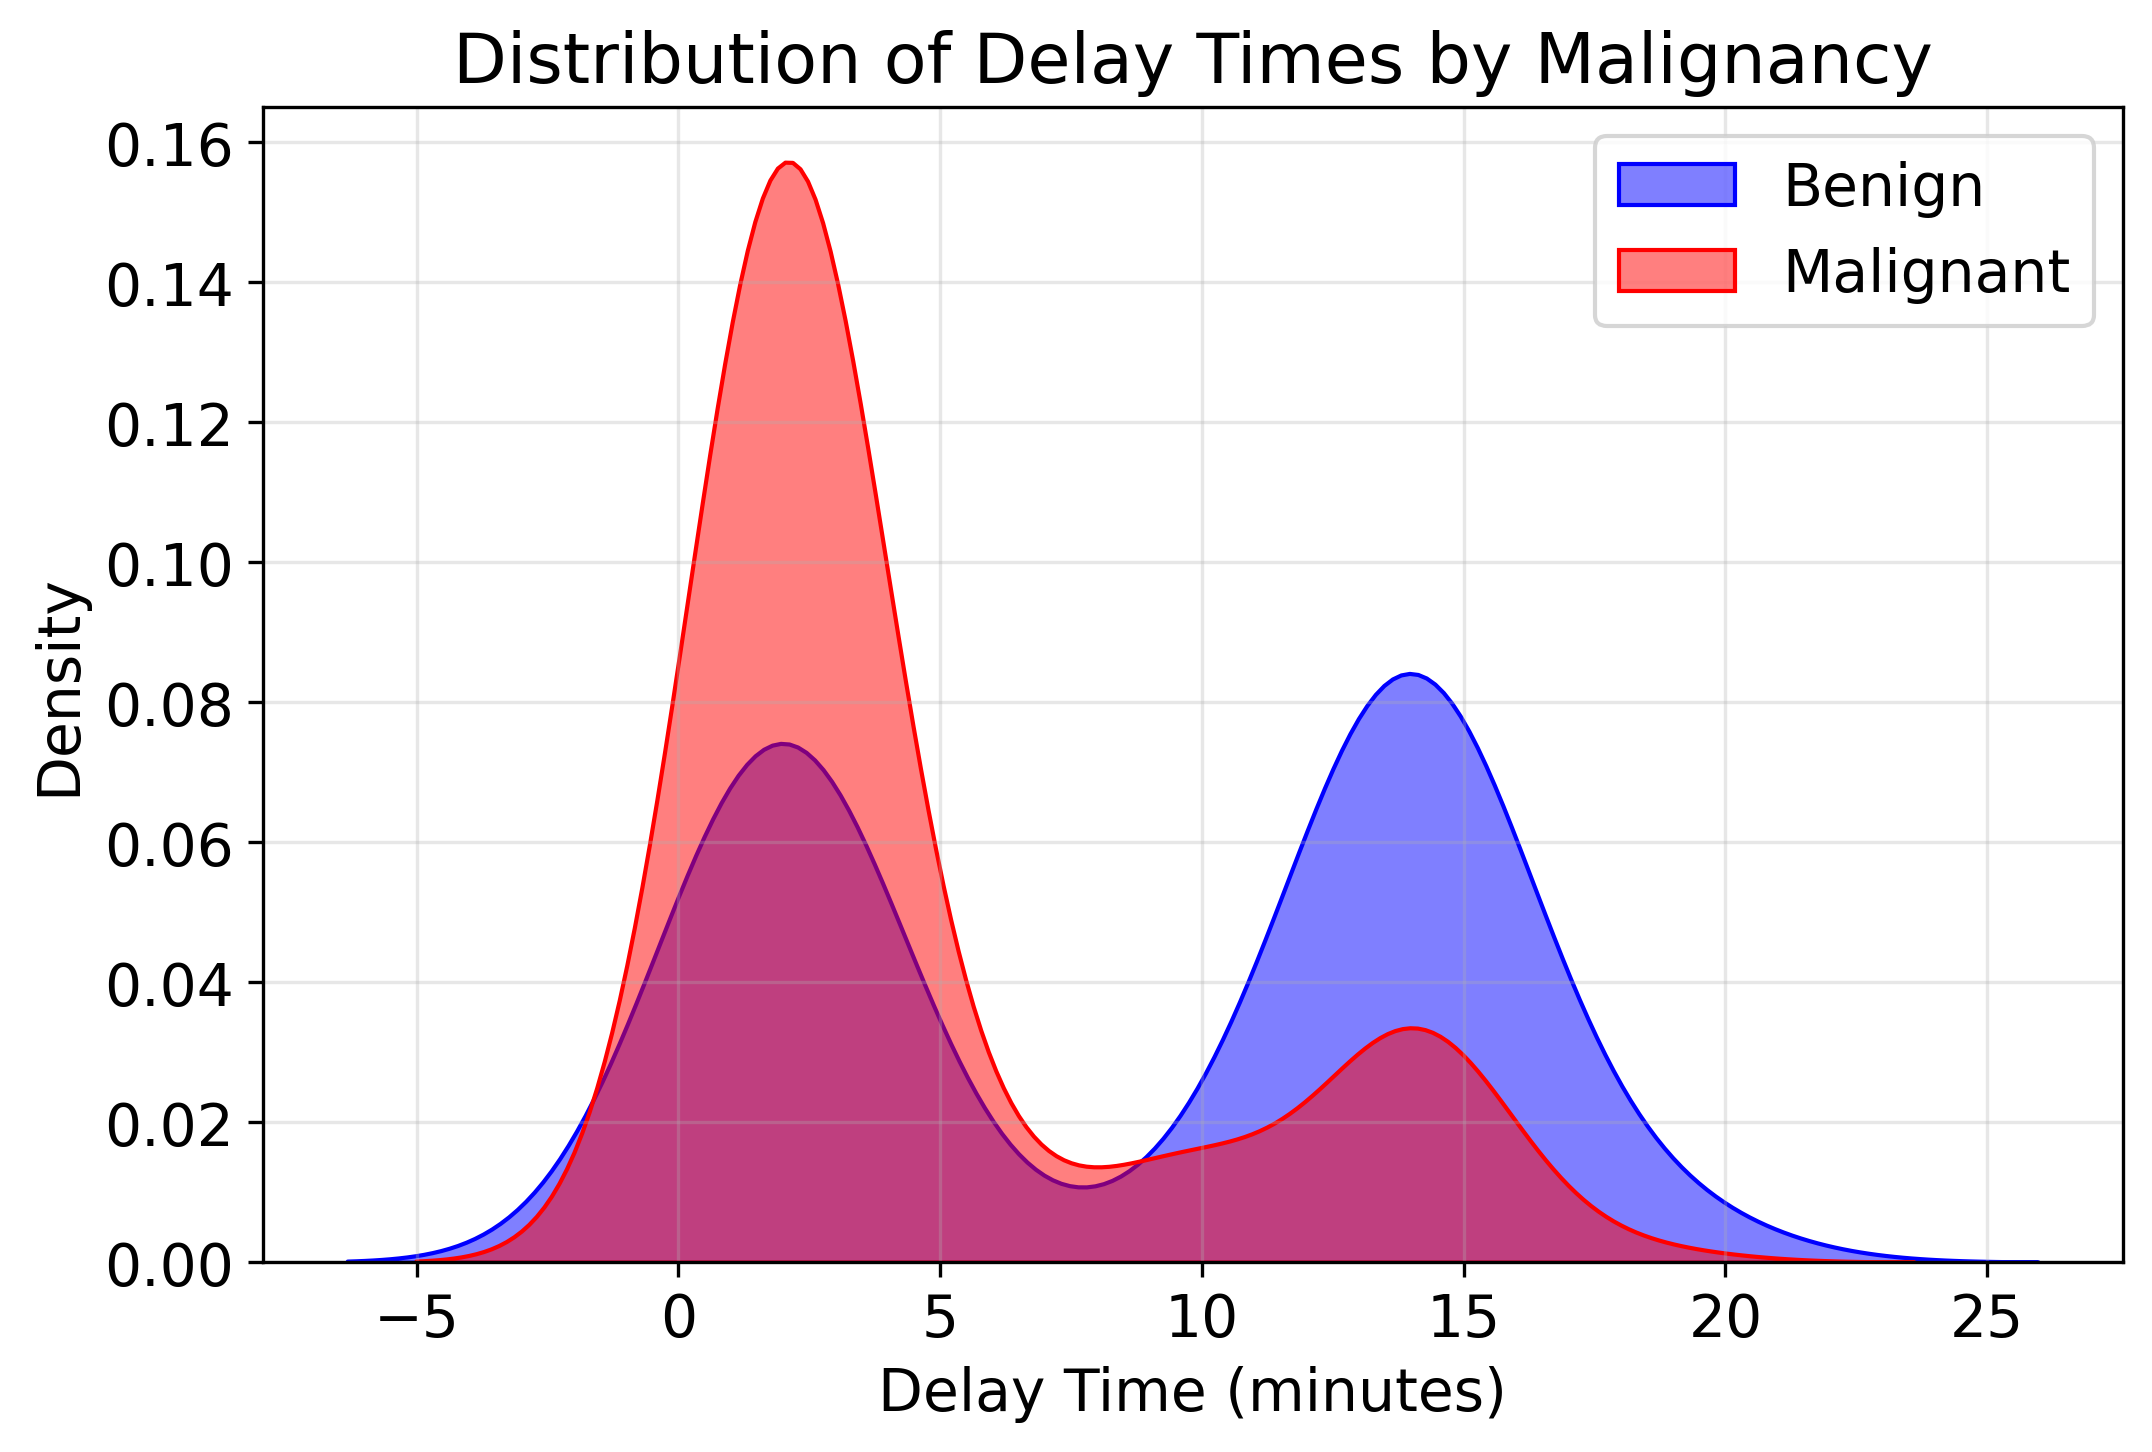

In [90]:
#draw plot, x-axis is delay time, y-axis is count of benign cases (KDE smoothed), line color code by benign vs malignant
plt.figure(figsize=(8, 5), dpi=300)
for malignancy, color in zip([0, 1], ['blue', 'red']):
    subset = merged_df_all[merged_df_all["malignancy"] == malignancy]
    label = 'Benign' if malignancy == 0 else 'Malignant'
    sns.kdeplot(subset["DelayTime"], label=label, color=color, fill=True, alpha=0.5)
plt.xlabel('Delay Time (minutes)')
plt.ylabel('Density')
plt.title('Distribution of Delay Times by Malignancy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()